In [40]:
import os

# Эти переменные нужно выставить ДО импорта transformers/tokenizers
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import gc
import json
import numpy as np
import pandas as pd
import torch

from transformers import AutoModelForCausalLM, AutoTokenizer

In [41]:
# 1. ПРОВЕРКА CUDA
print("PyTorch:", torch.__version__)
print("CUDA доступна:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM: {total_vram:.2f} GB")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используем:", DEVICE)

PyTorch: 2.6.0+cu124
CUDA доступна: True
CUDA version: 12.4
GPU: NVIDIA GeForce RTX 4060
VRAM: 8.00 GB
Используем: cuda


In [42]:
# 2. BINOCULARS FEATURE EXTRACTOR
class BinocularsFeatureExtractor:
    def __init__(self, observer_name="gpt2", performer_name="gpt2-medium", device=DEVICE):
        self.device = torch.device(device)

        print("\nЗАГРУЗКА BINOCULARS")
        print(f"Observer : {observer_name}")
        print(f"Performer: {performer_name}")
        print(f"Device   : {self.device}")

        self.tokenizer = AutoTokenizer.from_pretrained(observer_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        dtype = torch.float16 if self.device.type == "cuda" else torch.float32

        print("\nЗагрузка observer...")
        self.observer = AutoModelForCausalLM.from_pretrained(observer_name, torch_dtype=dtype, low_cpu_mem_usage=True)

        print("Загрузка performer...")
        self.performer = AutoModelForCausalLM.from_pretrained(performer_name, torch_dtype=dtype, low_cpu_mem_usage=True)

        self.observer = self.observer.to(self.device)
        self.performer = self.performer.to(self.device)

        self.observer.eval()
        self.performer.eval()
        self.observer.config.use_cache = False
        self.performer.config.use_cache = False

        gc.collect()
        if self.device.type == "cuda":
            torch.cuda.empty_cache()
            self.print_cuda_memory("После загрузки моделей")

        print("\nМодели успешно загружены.\n")

    def print_cuda_memory(self, title=""):
        if self.device.type != "cuda":
            return
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"[GPU] {title} | allocated={allocated:.2f} GB | reserved={reserved:.2f} GB")

    @torch.inference_mode()
    def calculate_score_from_ids(self, input_ids):
        attention_mask = torch.ones_like(input_ids)

        obs_output = self.observer(input_ids=input_ids, attention_mask=attention_mask, use_cache=False)
        obs_logits = obs_output.logits[..., :-1, :].float()
        shift_labels = input_ids[..., 1:]

        obs_log_probs = torch.log_softmax(obs_logits, dim=-1)
        obs_gathered = torch.gather(obs_log_probs, dim=-1, index=shift_labels.unsqueeze(-1)).squeeze(-1)
        log_ppl = -obs_gathered.mean().item()
        
        del obs_output

        perf_output = self.performer(input_ids=input_ids, attention_mask=attention_mask, use_cache=False)
        perf_logits = perf_output.logits[..., :-1, :].float()

        perf_log_probs = torch.log_softmax(perf_logits, dim=-1)
        perf_probs = torch.exp(perf_log_probs)
        cross_entropy = -(perf_probs * obs_log_probs).sum(dim=-1)
        log_x_ppl = cross_entropy.mean().item()

        score = log_ppl / log_x_ppl if log_x_ppl != 0 else 1.0

        del obs_logits, perf_logits, obs_log_probs, perf_log_probs, perf_probs, cross_entropy, perf_output, attention_mask
        if self.device.type == "cuda":
            torch.cuda.empty_cache()

        return float(score)

    @torch.inference_mode()
    def extract_window_features(self, text, window_size=50, step=15):
        if not text or len(text.strip()) < 10:
            return 1.0, 1.0, 0.0

        try:
            inputs = self.tokenizer(text, return_tensors="pt", truncation=False)
            input_ids = inputs["input_ids"].to(self.device)
            total_tokens = input_ids.shape[1]

            if total_tokens <= window_size:
                score = self.calculate_score_from_ids(input_ids)
                del input_ids
                if self.device.type == "cuda":
                    torch.cuda.empty_cache()
                return float(score), float(score), 0.0

            scores = []
            for start in range(0, total_tokens - window_size + 1, step):
                window_ids = input_ids[:, start:start + window_size]
                score = self.calculate_score_from_ids(window_ids)
                scores.append(score)
                print(f"    окно {start:4d}-{start + window_size:4d} score={score:.6f}")
                
                del window_ids
                if self.device.type == "cuda":
                    torch.cuda.empty_cache()
            
            del input_ids
            if not scores:
                return 1.0, 1.0, 0.0

            scores = np.asarray(scores, dtype=np.float32)
            return float(np.min(scores)), float(np.mean(scores)), float(np.var(scores))
            
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("\n!!! CUDA OUT OF MEMORY !!!")
                if self.device.type == "cuda":
                    torch.cuda.empty_cache()
                gc.collect()
                return 1.0, 1.0, 0.0
            raise
        except Exception as e:
            print(f"Ошибка обработки текста: {type(e).__name__}: {e}")
            return 1.0, 1.0, 0.0

In [43]:
# 3. ИНИЦИАЛИЗАЦИЯ
extractor = BinocularsFeatureExtractor(observer_name="gpt2", performer_name="gpt2-medium", device=DEVICE)


ЗАГРУЗКА BINOCULARS
Observer : gpt2
Performer: gpt2-medium
Device   : cuda

Загрузка observer...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3356.55it/s]


Загрузка performer...


Loading weights: 100%|██████████| 292/292 [00:00<00:00, 2919.56it/s]


[GPU] После загрузки моделей | allocated=1.82 GB | reserved=1.86 GB

Модели успешно загружены.



In [44]:
# 4. СОЗДАНИЕ FEATURE DATASET
def build_final_parquet(jsonl_input_path, parquet_output_path):
    if not os.path.exists(jsonl_input_path):
        print(f"[Ошибка] Файл {jsonl_input_path} не найден!")
        return None

    print("\nЧТЕНИЕ JSONL")
    records = []
    with open(jsonl_input_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"[WARNING] Пропускаю битую строку: {e}")

    # print(f"Загружено записей: {len(records)}")
    # ml_data = []

    # for idx, row in enumerate(records):
    #     print(f"\n[{idx + 1}/{len(records)}] Email ID: {row.get('email_id')}")
    #     orig_body = str(row.get("original_body", ""))
    #     ai_body = str(row.get("ai_mutated_body", ""))
    #     email_id = str(row.get("email_id"))
    #     var_idx = row.get("variant_index", 0)

    #     print("  -> Human text")
    #     o_min, o_mean, o_var = extractor.extract_window_features(orig_body)
    #     ml_data.append({
    #         "email_id": email_id, "variant_index": var_idx, "text_type": "Human", "is_ai": 0,
    #         "bino_min": o_min, "bino_mean": o_mean, "bino_var": o_var,
    #     })

    #     print("  -> AI text")
    #     a_min, a_mean, a_var = extractor.extract_window_features(ai_body)
    #     ml_data.append({
    #         "email_id": email_id, "variant_index": var_idx, "text_type": "AI", "is_ai": 1,
    #         "bino_min": a_min, "bino_mean": a_mean, "bino_var": a_var,
    #     })

    #     gc.collect()
    #     if DEVICE.type == "cuda":
    #         torch.cuda.empty_cache()
    #     extractor.print_cuda_memory(f"После Email {idx + 1}")

    # print("\nСоздаю DataFrame...")
    # df = pd.DataFrame(ml_data)
    print(f"Загружено записей: {len(records)}")
    ml_data = []
    processed_human_emails = set() # Множество для отслеживания уже посчитанных оригиналов

    for idx, row in enumerate(records):
        print(f"\n[{idx + 1}/{len(records)}] Email ID: {row.get('email_id')}")
        orig_body = str(row.get("original_body", ""))
        ai_body = str(row.get("ai_mutated_body", ""))
        email_id = str(row.get("email_id"))
        var_idx = row.get("variant_index", 0)

        # 1. Считаем Human text ТОЛЬКО если мы его еще не считали для этого email_id
        if email_id not in processed_human_emails:
            print("  -> Human text")
            o_min, o_mean, o_var = extractor.extract_window_features(orig_body)
            ml_data.append({
                "email_id": email_id, "variant_index": -1, "text_type": "Human", "is_ai": 0,
                "bino_min": o_min, "bino_mean": o_mean, "bino_var": o_var,
            })
            processed_human_emails.add(email_id)
        else:
            print("  -> Human text (пропущен, уже посчитан)")

        # 2. AI text считаем всегда (они разные)
        print("  -> AI text")
        a_min, a_mean, a_var = extractor.extract_window_features(ai_body)
        ml_data.append({
            "email_id": email_id, "variant_index": var_idx, "text_type": "AI", "is_ai": 1,
            "bino_min": a_min, "bino_mean": a_mean, "bino_var": a_var,
        })

        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        extractor.print_cuda_memory(f"После Email {idx + 1}")

    print("\nСоздаю DataFrame...")
    df = pd.DataFrame(ml_data)
    print("\nПервые строки:\n", df.head())
    print("\nРазмер:\n", df.shape)

    csv_output = parquet_output_path.replace(".parquet", ".csv")
    df.to_csv(csv_output, index=False, encoding="utf-8")
    print(f"\nCSV сохранён: {csv_output}")

    df.to_parquet(parquet_output_path, engine="pyarrow", index=False)
    print(f"Parquet сохранён: {parquet_output_path}")

    return df

In [45]:
# 5. ЗАПУСК
df = build_final_parquet(jsonl_input_path="mutated_spam_dataset.jsonl", parquet_output_path="final_features.parquet")


ЧТЕНИЕ JSONL
Загружено записей: 100

[1/100] Email ID: 0
  -> Human text
    окно    0-  50 score=1.004529
    окно   15-  65 score=1.055443
    окно   30-  80 score=1.032449
    окно   45-  95 score=1.024822
    окно   60- 110 score=0.922526
    окно   75- 125 score=0.874195
    окно   90- 140 score=0.845401
    окно  105- 155 score=0.948323
  -> AI text
    окно    0-  50 score=0.927185
    окно   15-  65 score=1.050168
    окно   30-  80 score=0.924135
    окно   45-  95 score=0.885518
    окно   60- 110 score=0.963588
    окно   75- 125 score=1.014540
    окно   90- 140 score=1.085026
[GPU] После Email 1 | allocated=0.92 GB | reserved=1.47 GB

[2/100] Email ID: 0
  -> Human text (пропущен, уже посчитан)
  -> AI text
    окно    0-  50 score=0.917815
    окно   15-  65 score=0.921014
    окно   30-  80 score=0.985454
    окно   45-  95 score=0.997829
    окно   60- 110 score=0.960511
    окно   75- 125 score=0.930723
    окно   90- 140 score=1.005207
[GPU] После Email 2 | allocated

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1552 > 1024). Running this sequence through the model will result in indexing errors


[GPU] После Email 61 | allocated=0.92 GB | reserved=1.47 GB

[62/100] Email ID: 31
  -> Human text (пропущен, уже посчитан)
  -> AI text
[GPU] После Email 62 | allocated=0.92 GB | reserved=1.47 GB

[63/100] Email ID: 32
  -> Human text
    окно    0-  50 score=1.267128
    окно   15-  65 score=1.314745
    окно   30-  80 score=1.441940
    окно   45-  95 score=1.423711
    окно   60- 110 score=1.275392
    окно   75- 125 score=1.186164
    окно   90- 140 score=1.112268
    окно  105- 155 score=1.309345
    окно  120- 170 score=1.262850
    окно  135- 185 score=1.154416
    окно  150- 200 score=1.240662
    окно  165- 215 score=1.265582
    окно  180- 230 score=1.189936
    окно  195- 245 score=1.320130
    окно  210- 260 score=1.332196
    окно  225- 275 score=1.186164
    окно  240- 290 score=1.112268
    окно  255- 305 score=1.309345
    окно  270- 320 score=1.262850
    окно  285- 335 score=1.154416
    окно  300- 350 score=1.240662
    окно  315- 365 score=1.265582
    окно  330- 3

In [46]:
# 6. ПРОВЕРКА
if df is not None:
    print("\nИТОГОВЫЙ DATASET")
    print(df)
    print("\nРазмер:", df.shape)
    print("\nРаспределение классов:\n", df["is_ai"].value_counts())


ИТОГОВЫЙ DATASET
    email_id  variant_index text_type  is_ai  bino_min  bino_mean  bino_var
0          0             -1     Human      0  0.845401   0.963461  0.005310
1          0              0        AI      1  0.885518   0.978594  0.004606
2          0              1        AI      1  0.917815   0.959794  0.001183
3          1             -1     Human      0  0.970504   1.025985  0.001314
4          1              0        AI      1  0.903101   1.001675  0.006695
..       ...            ...       ...    ...       ...        ...       ...
145       49              0        AI      1  0.737015   0.904524  0.006386
146       49              1        AI      1  0.887594   0.908146  0.000693
147       50             -1     Human      0  1.118544   1.129710  0.000125
148       50              0        AI      1  1.016731   1.016731  0.000000
149       50              1        AI      1  0.926738   0.926738  0.000000

[150 rows x 7 columns]

Размер: (150, 7)

Распределение классов:
 is_

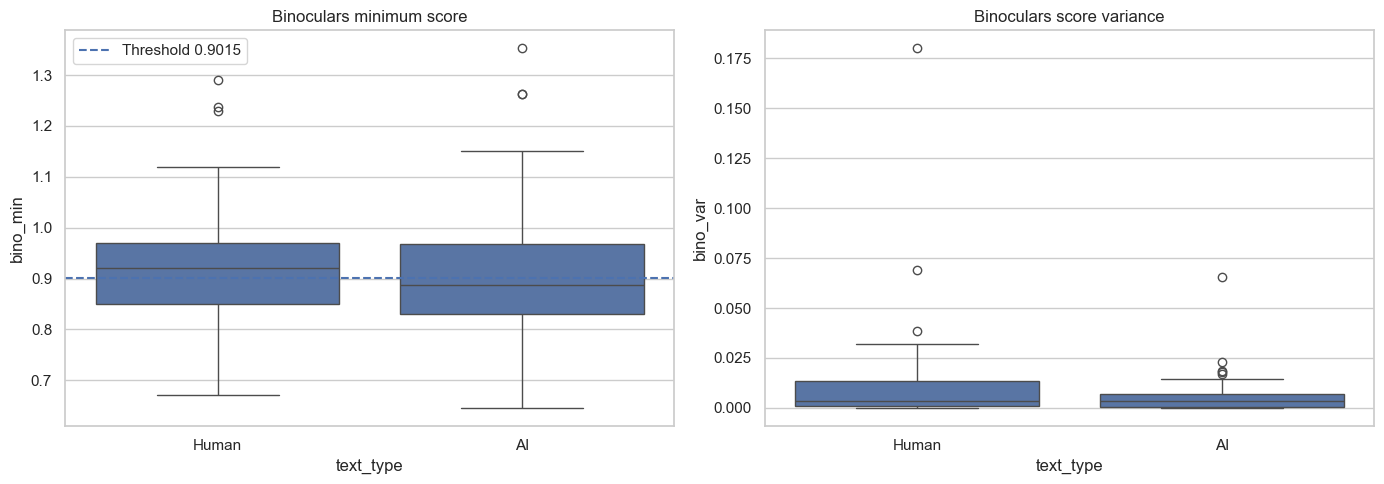

In [47]:
# 7. ГРАФИКИ
if df is not None:
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=df, x="text_type", y="bino_min", ax=axes[0])
    axes[0].axhline(y=0.9015, linestyle="--", linewidth=1.5, label="Threshold 0.9015")
    axes[0].set_title("Binoculars minimum score")
    axes[0].legend()

    sns.boxplot(data=df, x="text_type", y="bino_var", ax=axes[1])
    axes[1].set_title("Binoculars score variance")

    plt.tight_layout()
    plt.show()

In [53]:
import json
import pandas as pd
from catboost import CatBoostClassifier

# --- 1. ОБУЧЕНИЕ МОДЕЛИ ---
def train_detector(csv_path="final_features.csv"):
    print("Загрузка данных для обучения...")
    df = pd.read_csv(csv_path)
    
    # Защита от битых строк
    df = df.dropna(subset=['bino_min', 'bino_mean', 'bino_var', 'is_ai'])
    
    # Формируем X и y
    X = df[['bino_min', 'bino_mean', 'bino_var']]
    y = df['is_ai']
    
    # Инициализация легкой модели (защита от переобучения на малом датасете)
    model = CatBoostClassifier(
        iterations=50, 
        depth=3, 
        learning_rate=0.1, 
        verbose=False,
        random_seed=42
    )
    
    model.fit(X, y)
    print("Модель CatBoost успешно обучена!")
    return model

# Обучаем модель один раз
cb_model = train_detector("final_features.csv")



Загрузка данных для обучения...
Модель CatBoost успешно обучена!


In [56]:

# --- 2. ИНФЕРЕНС (ПАЙПЛАЙН) ---
def predict_email(raw_input, extractor_instance, model):
    """
    Принимает строку (текст или JSON), экстрактор и модель.
    Возвращает словарь с предсказанием.
    """
    text_to_check = ""
    #text_to_check = "[NAME],\nAs part of independence issues, the requesting group / VP should be [ORGANIZATION] (i.e. not [ORGANIZATION]).  Who would be appropriate?\n\n[INITIALS]\tCSC Work Request\n\nFYI, here is a copy of the work request I have forwarded to [NAME].\n\nRegards"
    #text_to_check = "[NAME],\nFor independence, the requesting group/VP should be [ORGANIZATION], not [ORGANIZATION]. Who fits?\n\n[INITIALS]\tCSC Work Request\n\nFYI, forwarded work request to [NAME].\n\nRegards"
    # 1. Парсинг ввода (если передали JSON строку)
    try:
        data = json.loads(raw_input)
        # Если это твой формат, достаем тело. Иначе берем как сырой текст.
        text_to_check = data.get("body") or data.get("ai_mutated_body") or data.get("original_body", "")
    except json.JSONDecodeError:
        # Если передали обычную строку, а не JSON
        text_to_check = raw_input

    if not text_to_check or len(text_to_check.strip()) < 10:
        return {"error": "Текст отсутствует или слишком короткий для детекции."}

    # 2. Извлечение признаков через GPU
    b_min, b_mean, b_var = extractor_instance.extract_window_features(text_to_check)
    
    # 3. Формирование вектора для CatBoost
    X_infer = pd.DataFrame({
        'bino_min': [b_min],
        'bino_mean': [b_mean],
        'bino_var': [b_var]
    })
    
    # 4. Предсказание
    prob_ai = model.predict_proba(X_infer)[0][1] # Вероятность класса 1 (ИИ)
    is_ai = int(model.predict(X_infer)[0])
    
    return {
        "prediction": "AI Generated" if is_ai == 1 else "Human Written",
        "confidence": f"{prob_ai * 100:.2f}%",
        "features": {
            "bino_min": round(b_min, 4),
            "bino_mean": round(b_mean, 4),
            "bino_var": round(b_var, 6)
        }
    }

# --- 3. ТЕСТОВЫЙ ЗАПУСК ---
# Передаем сырой JSON, который мог прийти от клиента/API
test_json = '{"email_id": 99, "ai_mutated_body": "[NAME],\nFor independence, the requesting group/VP should be [ORGANIZATION], not [ORGANIZATION]. Who fits?\n\n[INITIALS]\tCSC Work Request\n\nFYI, forwarded work request to [NAME].\n\nRegards"}'

# ВАЖНО: 'extractor' - это переменная твоего класса BinocularsFeatureExtractor из прошлого кода
result = predict_email(test_json, extractor, cb_model)
print("\nРезультат проверки:")
print(json.dumps(result, indent=2, ensure_ascii=False))

    окно    0-  50 score=1.082028
    окно   15-  65 score=1.157412

Результат проверки:
{
  "prediction": "AI Generated",
  "confidence": "67.94%",
  "features": {
    "bino_min": 1.082,
    "bino_mean": 1.1197,
    "bino_var": 0.001421
  }
}
